# 7.4.含并行连结的网络（GoogLeNet）

在2014年的ImageNet图像识别挑战赛中，一个名叫*GoogLeNet* [[Szegedy et al., 2015]](https://zh.d2l.ai/chapter_references/zreferences.html#id162)的网络架构大放异彩。GoogLeNet吸收了NiN中串联网络的思想，并在此基础上做了改进。这篇论文的一个重点是解决了什么样大小的卷积核最合适的问题。毕竟，以前流行的网络使用小到$1 \times 1$，大到$11 \times 11$的卷积核。本文的一个观点是，有时使用不同大小的卷积核组合是有利的。本节将介绍一个稍微简化的GoogLeNet版本：我们省略了一些为稳定训练而添加的特殊特性，现在有了更好的训练方法，这些特性不是必要的。



---


## 环境准备


In [ ]:
%matplotlib inline
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear

import pypto
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from src.D2LFunction import *

---


## 7.4.1.Inception块

在GoogLeNet中，基本的卷积块被称为*Inception块*（Inception block）。这很可能得名于电影《盗梦空间》（Inception），因为电影中的一句话“我们需要走得更深”（“We need to go deeper”）。

<div style="border: solid 16px #f1f1f8; text-align: center; background-color: #f6f7f9">
<img src="./images/inception.svg">
<p style="margin: 12px 0 4px 0; font-size: 0.9em; color: #555; text-align: center;">图7.4.1 Inception块的架构。</p>
</div>
<br />

如 <span style="color: #ffbf00; font-weight: bold;"> 图7.4.1 </span>所示，Inception块由四条并行路径组成。前三条路径使用窗口大小为$1\times 1$、$3\times 3$和$5\times 5$的卷积层，从不同空间大小中提取信息。中间的两条路径在输入上执行$1\times 1$卷积，以减少通道数，从而降低模型的复杂性。第四条路径使用$3\times 3$最大汇聚层，然后使用$1\times 1$卷积层来改变通道数。这四条路径都使用合适的填充来使输入与输出的高和宽一致，最后我们将每条线路的输出在通道维度上连结，并构成Inception块的输出。在Inception块中，通常调整的超参数是每层输出通道数。


In [2]:
class Inception(nn.Module):
    # c1--c4是每条路径的输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 线路1，单1x1卷积层
        self.p1_1 = PyPTOConv2d(in_channels, c1, kernel_size=1, bias=True)
        # 线路2，1x1卷积层后接3x3卷积层
        self.p2_1 = PyPTOConv2d(in_channels, c2[0], kernel_size=1, bias=True)
        self.p2_2 = PyPTOConv2d(c2[0], c2[1], kernel_size=3, padding=1, bias=True)
        # 线路3，1x1卷积层后接5x5卷积层
        self.p3_1 = PyPTOConv2d(in_channels, c3[0], kernel_size=1, bias=True)
        self.p3_2 = PyPTOConv2d(c3[0], c3[1], kernel_size=5, padding=2, bias=True)
        # 线路4，3x3最大汇聚层后接1x1卷积层
        self.p4_1 = PyPTOMaxPool2d(3, 1, 1)
        self.p4_2 = PyPTOConv2d(in_channels, c4, kernel_size=1, bias=True)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # 在通道维度上连结输出
        return torch.cat((p1, p2, p3, p4), dim=1)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">class Inception(nn.Module):
    # c1--c4是每条路径的输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 线路1，单1x1卷积层
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        # 线路2，1x1卷积层后接3x3卷积层
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        # 线路3，1x1卷积层后接5x5卷积层
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        # 线路4，3x3最大汇聚层后接1x1卷积层
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)</br>
    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # 在通道维度上连结输出
        return torch.cat((p1, p2, p3, p4), dim=1)</pre>
</div>
</details>

那么为什么GoogLeNet这个网络如此有效呢？首先我们考虑一下滤波器（filter）的组合，它们可以用各种滤波器尺寸探索图像，这意味着不同大小的滤波器可以有效地识别不同范围的图像细节。同时，我们可以为不同的滤波器分配不同数量的参数。



---


## 7.4.2.GoogLeNet模型

如 <span style="color: #ffbf00; font-weight: bold;"> 图7.4.2 </span>所示，GoogLeNet一共使用9个Inception块和全局平均汇聚层的堆叠来生成其估计值。Inception块之间的最大汇聚层可降低维度。第一个模块类似于AlexNet和LeNet，Inception块的组合从VGG继承，全局平均汇聚层避免了在最后使用全连接层。

<div style="border: solid 16px #f1f1f8; text-align: center; background-color: #f6f7f9">
<img src="./images/inception-full.svg">
<p style="margin: 12px 0 4px 0; font-size: 0.9em; color: #555; text-align: center;">图7.4.2 GoogLeNet架构。</p>
</div>
<br />

现在，我们逐一实现GoogLeNet的每个模块。第一个模块使用64个通道、$7\times 7$卷积层。


In [3]:
b1 = nn.Sequential(PyPTOConv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=True),
                   nn.ReLU(),
                   PyPTOMaxPool2d(3, 2, 1))

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))</pre>
</div>
</details>

第二个模块使用两个卷积层：第一个卷积层是64个通道、$1\times 1$卷积层；第二个卷积层使用将通道数量增加三倍的$3\times 3$卷积层。这对应于Inception块中的第二条路径。


In [4]:
b2 = nn.Sequential(PyPTOConv2d(64, 64, kernel_size=1, bias=True),
                   nn.ReLU(),
                   PyPTOConv2d(64, 192, kernel_size=3, padding=1, bias=True),
                   nn.ReLU(),
                   PyPTOMaxPool2d(3, 2, 1))

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">b2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1),
                   nn.ReLU(),
                   nn.Conv2d(64, 192, kernel_size=3, padding=1),
                   nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))</pre>
</div>
</details>

第三个模块串联两个完整的Inception块。第一个Inception块的输出通道数为$64+128+32+32=256$，四个路径之间的输出通道数量比为$64:128:32:32=2:4:1:1$。第二个和第三个路径首先将输入通道的数量分别减少到$96/192=1/2$和$16/192=1/12$，然后连接第二个卷积层。第二个Inception块的输出通道数增加到$128+192+96+64=480$，四个路径之间的输出通道数量比为$128:192:96:64 = 4:6:3:2$。第二条和第三条路径首先将输入通道的数量分别减少到$128/256=1/2$和$32/256=1/8$。


In [5]:
b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32),
                   Inception(256, 128, (128, 192), (32, 96), 64),
                   PyPTOMaxPool2d(3, 2, 1))

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32),
                   Inception(256, 128, (128, 192), (32, 96), 64),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))</pre>
</div>
</details>

第四模块更加复杂，它串联了5个Inception块，其输出通道数分别是$192+208+48+64=512$、$160+224+64+64=512$、$128+256+64+64=512$、$112+288+64+64=528$和$256+320+128+128=832$。这些路径的通道数分配和第三模块中的类似，首先是含$3×3$卷积层的第二条路径输出最多通道，其次是仅含$1×1$卷积层的第一条路径，之后是含$5×5$卷积层的第三条路径和含$3×3$最大汇聚层的第四条路径。其中第二、第三条路径都会先按比例减小通道数。这些比例在各个Inception块中都略有不同。


In [6]:
b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64),
                   Inception(512, 160, (112, 224), (24, 64), 64),
                   Inception(512, 128, (128, 256), (24, 64), 64),
                   Inception(512, 112, (144, 288), (32, 64), 64),
                   Inception(528, 256, (160, 320), (32, 128), 128),
                   PyPTOMaxPool2d(3, 2, 1))

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64),
                   Inception(512, 160, (112, 224), (24, 64), 64),
                   Inception(512, 128, (128, 256), (24, 64), 64),
                   Inception(512, 112, (144, 288), (32, 64), 64),
                   Inception(528, 256, (160, 320), (32, 128), 128),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))</pre>
</div>
</details>

第五模块包含输出通道数为$256+320+128+128=832$和$384+384+128+128=1024$的两个Inception块。其中每条路径通道数的分配思路和第三、第四模块中的一致，只是在具体数值上有所不同。需要注意的是，第五模块的后面紧跟输出层，该模块同NiN一样使用全局平均汇聚层，将每个通道的高和宽变成1。最后我们将输出变成二维数组，再接上一个输出个数为标签类别数的全连接层。


In [7]:
b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128),
                   Inception(832, 384, (192, 384), (48, 128), 128),
                   nn.AdaptiveAvgPool2d((1,1)),
                   nn.Flatten())

net = nn.Sequential(b1, b2, b3, b4, b5, PyPTOLinear(1024, 10)).to('npu:0')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128),
                   Inception(832, 384, (192, 384), (48, 128), 128),
                   nn.AdaptiveAvgPool2d((1,1)),
                   nn.Flatten())</br>
net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10))</pre>
</div>
</details>

GoogLeNet模型的计算复杂，而且不如VGG那样便于修改通道数。为了使Fashion-MNIST上的训练短小精悍，我们将输入的高和宽从224降到96，这简化了计算。下面演示各个模块输出的形状变化。


In [8]:
X = torch.rand(size=(1, 1, 96, 96), device='npu:0')
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 192, 12, 12])
Sequential output shape:	 torch.Size([1, 480, 6, 6])
Sequential output shape:	 torch.Size([1, 832, 3, 3])
Sequential output shape:	 torch.Size([1, 1024])
PyPTOLinear output shape:	 torch.Size([1, 10])


---


## 7.4.3.训练模型

和以前一样，我们使用Fashion-MNIST数据集来训练我们的模型。在训练之前，我们将图片转换为$96 \times 96$分辨率。


loss 0.171, train acc 0.935, test acc 0.888
81.6 examples/sec on npu:0


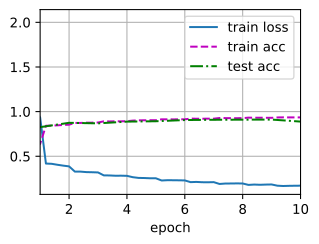

In [ ]:
lr, num_epochs, batch_size = 0.05, 10, 16
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=96)
train_ch6_sgd(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

---


## 7.4.4.小结

* Inception块相当于一个有4条路径的子网络。它通过不同窗口形状的卷积层和最大汇聚层来并行抽取信息，并使用$1×1$卷积层减少每像素级别上的通道维数从而降低模型复杂度。
*  GoogLeNet将多个设计精细的Inception块与其他层（卷积层、全连接层）串联起来。其中Inception块的通道数分配之比是在ImageNet数据集上通过大量的实验得来的。
* GoogLeNet和它的后继者们一度是ImageNet上最有效的模型之一：它以较低的计算复杂度提供了类似的测试精度。



---


## 7.4.5.练习

1. GoogLeNet有一些后续版本。尝试实现并运行它们，然后观察实验结果。这些后续版本包括：
    * 添加批量规范化层 [[Ioffe et al., 2015]](https://zh.d2l.ai/chapter_references/zreferences.html#id75)（batch normalization），在 [<span style="color: #ffbf00; font-weight: bold;"> 7.5节 </span>](./07.05_batch_norm.ipynb)中将介绍；
    * 对Inception模块进行调整 [[Szegedy et al., 2016]](https://zh.d2l.ai/chapter_references/zreferences.html#id163)；
    * 使用标签平滑（label smoothing）进行模型正则化 [[Szegedy et al., 2016]](https://zh.d2l.ai/chapter_references/zreferences.html#id163)；
    * 加入残差连接 [[Szegedy et al., 2017]](https://zh.d2l.ai/chapter_references/zreferences.html#id161)。（ [<span style="color: #ffbf00; font-weight: bold;"> 7.6节 </span>](./07.06_resnet.ipynb)将介绍）。
2. 使用GoogLeNet的最小图像大小是多少？
3. 将AlexNet、VGG和NiN的模型参数大小与GoogLeNet进行比较。后两个网络架构是如何显著减少模型参数大小的？


参考答案详见 [answers/07.04_reference_answer](./answers/07.04_reference_answer.ipynb)。

### 7.4.5.1.参考答案（PyPTO）


In [ ]:
!cat answers/txt/07.04_reference_answer_pypto.txt

### 7.4.5.2.参考答案（PyTorch）


In [ ]:
!cat answers/txt/07.04_reference_answer_pytorch.txt